# Week 02: Conceptual Soundness & EDA
## Practical Model Validation for Financial Risk — v2

| | |
|---|---|
| **Author** | *(Your name)* |
| **Date** | *(Today's date)* |
| **Purpose** | Document the Conceptual Soundness and EDA section of the validation report for the Give Me Some Credit PD model |
| **Dataset** | cs-training.csv (150,000 rows, 11 columns — split yourself in Week 3) |
| **Report section** | Section 1 — Conceptual Soundness & EDA |

**SR 11-7 reference:** Section I.A requires that model inputs be theoretically motivated and that data quality be assessed as part of model validation.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    sns.set(style='whitegrid', context='notebook')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data Loading

In [2]:
DATA_PATH = 'cs-training.csv'

df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nData types:')
print(df.dtypes)
df.head(3)

Shape: (150000, 11)
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Data types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000


### 1.1 Data Loading Validation

*(Your explanation here)*

As the validator, confirm:
- Does the shape match the data dictionary (150,000 rows, 10 features + 1 target)? 
- Are the column names consistent with the data dictionary?
- Are the data types as expected (numeric for all features)?
- Are there any immediately obvious anomalies in the first few rows?

## 2. Target Variable Distribution

The target variable is `SeriousDlqin2yrs`:
- **1** = serious delinquency within 2 years
- **0** = no serious delinquency

Default rate (SeriousDlqin2yrs = 1): 6.68%

Value counts:
0    139974
1     10026
Name: SeriousDlqin2yrs, dtype: int64

Proportions:
0   0.9332
1   0.0668
Name: SeriousDlqin2yrs, dtype: float64


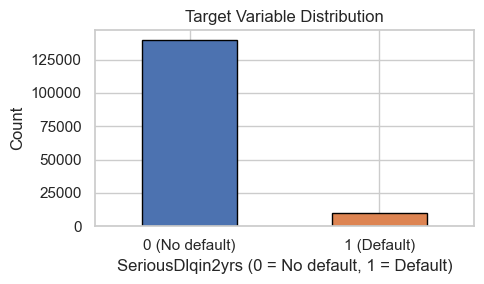

In [3]:
TARGET_COL = 'SeriousDlqin2yrs'

assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found."

target_rate = df[TARGET_COL].mean()
target_counts = df[TARGET_COL].value_counts()

print(f'Default rate (SeriousDlqin2yrs = 1): {target_rate:.2%}')
print(f'\nValue counts:')
print(target_counts)
print(f'\nProportions:')
print(df[TARGET_COL].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(5, 3))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
ax.set_title('Target Variable Distribution')
ax.set_xlabel('SeriousDlqin2yrs (0 = No default, 1 = Default)')
ax.set_ylabel('Count')
ax.set_xticklabels(['0 (No default)', '1 (Default)'], rotation=0)
plt.tight_layout()
plt.show()

### 2.1 Target Distribution — Validator Interpretation

*(Your explanation here)*

As the validator, address:
- What is the default rate? State it explicitly as a percentage.
- Is this materially imbalanced? What would class imbalance mean for model behavior?
- Is this rate plausible for a retail credit dataset from 2008–2009?

---

> **Containment note:** You have just observed the class imbalance. The question *"Should I use `class_weight='balanced'`?"* is coming in **Week 3** (modeling response) and **Week 4** (calibration consequences — why it inflates predicted PD levels).  
> For now: document the imbalance, note it as a data characteristic, and move on.  
> Write: *"The dataset is materially imbalanced ([X]% positive class). Implications for modeling and calibration are addressed in Sections 2 and 3 of this report (Weeks 3–4)."*

## 3. Missing Value Analysis

Missing values by column:
                                      missing_count  missing_pct
MonthlyIncome                                 29731      19.8207
NumberOfDependents                             3924       2.6160
SeriousDlqin2yrs                                  0       0.0000
RevolvingUtilizationOfUnsecuredLines              0       0.0000
age                                               0       0.0000
NumberOfTime30-59DaysPastDueNotWorse              0       0.0000
DebtRatio                                         0       0.0000
NumberOfOpenCreditLinesAndLoans                   0       0.0000
NumberOfTimes90DaysLate                           0       0.0000
NumberRealEstateLoansOrLines                      0       0.0000
NumberOfTime60-89DaysPastDueNotWorse              0       0.0000

Columns with >5% missing: ['MonthlyIncome']


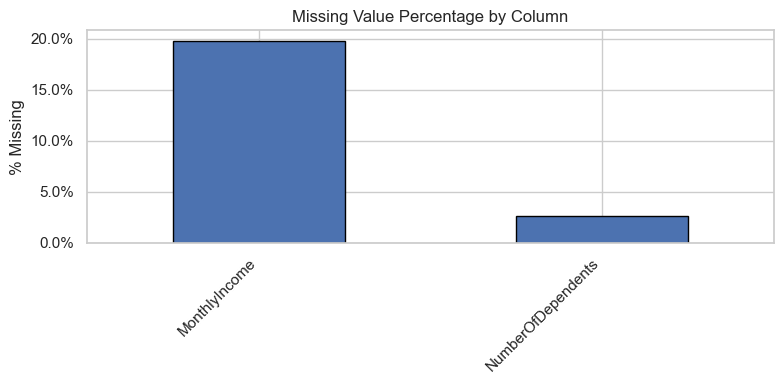

In [4]:
missing_counts = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('Missing values by column:')
print(missing_df.to_string())
print(f"\nColumns with >5% missing: {list(missing_df[missing_df['missing_pct'] > 5].index)}")

# Bar chart of missingness
missing_pct_nonzero = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_pct_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_pct_nonzero.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 3.1 Missing Value Analysis — Validator Interpretation

*(Your explanation here)*

For each variable with >1% missing, document using this structure:

**Variable: [name]**
- **Missing:** [count] rows ([X]%)
- **Is the missingness likely random, or might it be informative?** (Could the fact that a value is missing itself predict the outcome?)
- **Proposed treatment:** [drop rows / impute with mean/median/mode / impute by group / create missingness indicator / leave as-is]
- **Rationale:** [why is this defensible for this variable?]
- **Limitation:** [what signal might be lost? what assumption does this impose?]

Minimum: document **MonthlyIncome** and **NumberOfDependents** in full.

Quality bar (anonymized v1 exemplar): *"There are 29,731 rows with missing MonthlyIncome (21.0%). Median imputation by age band was applied rather than global median, because income varies substantially by age group. Limitation: this approach loses the signal that missingness on MonthlyIncome may itself be informative of financial distress — flagged as a model limitation."*

## 4. Variable Distributions

In [5]:
numeric_feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                        if c != TARGET_COL]

print('Numeric features summary:')
df[numeric_feature_cols].describe().T.round(2)

Numeric features summary:


,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0500,249.7600,0.0000,0.0300,0.1500,0.5600,50708.0000
age,150000.0000,52.3000,14.7700,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4200,4.1900,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,150000.0000,353.0100,2037.8200,0.0000,0.1800,0.3700,0.8700,329664.0000
MonthlyIncome,120269.0000,6670.2200,14384.6700,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4500,5.1500,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2700,4.1700,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0200,1.1300,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2400,4.1600,0.0000,0.0000,0.0000,0.0000,98.0000
NumberOfDependents,146076.0000,0.7600,1.1200,0.0000,0.0000,0.0000,1.0000,20.0000


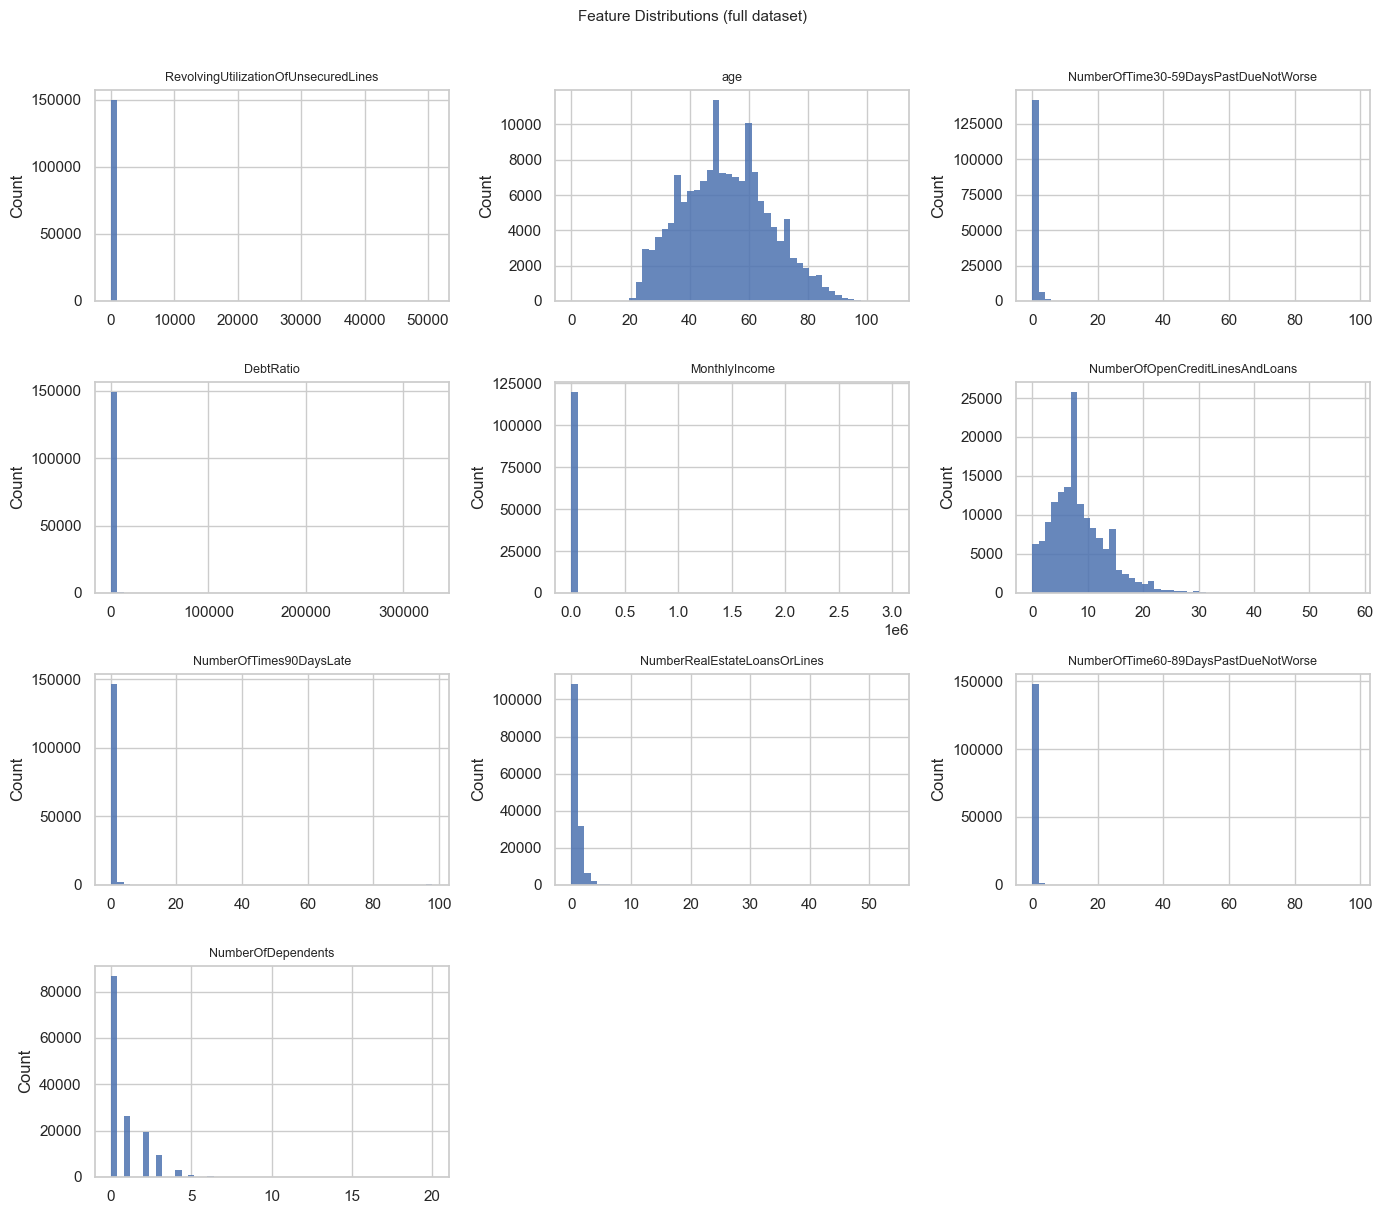

In [6]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_feature_cols):
    axes_flat[i].hist(df[col].dropna(), bins=50, color='#4C72B0', edgecolor='none', alpha=0.85)
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_ylabel('Count')

for j in range(len(numeric_feature_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Distributions (full dataset)', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

Numeric feature columns used for plots:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


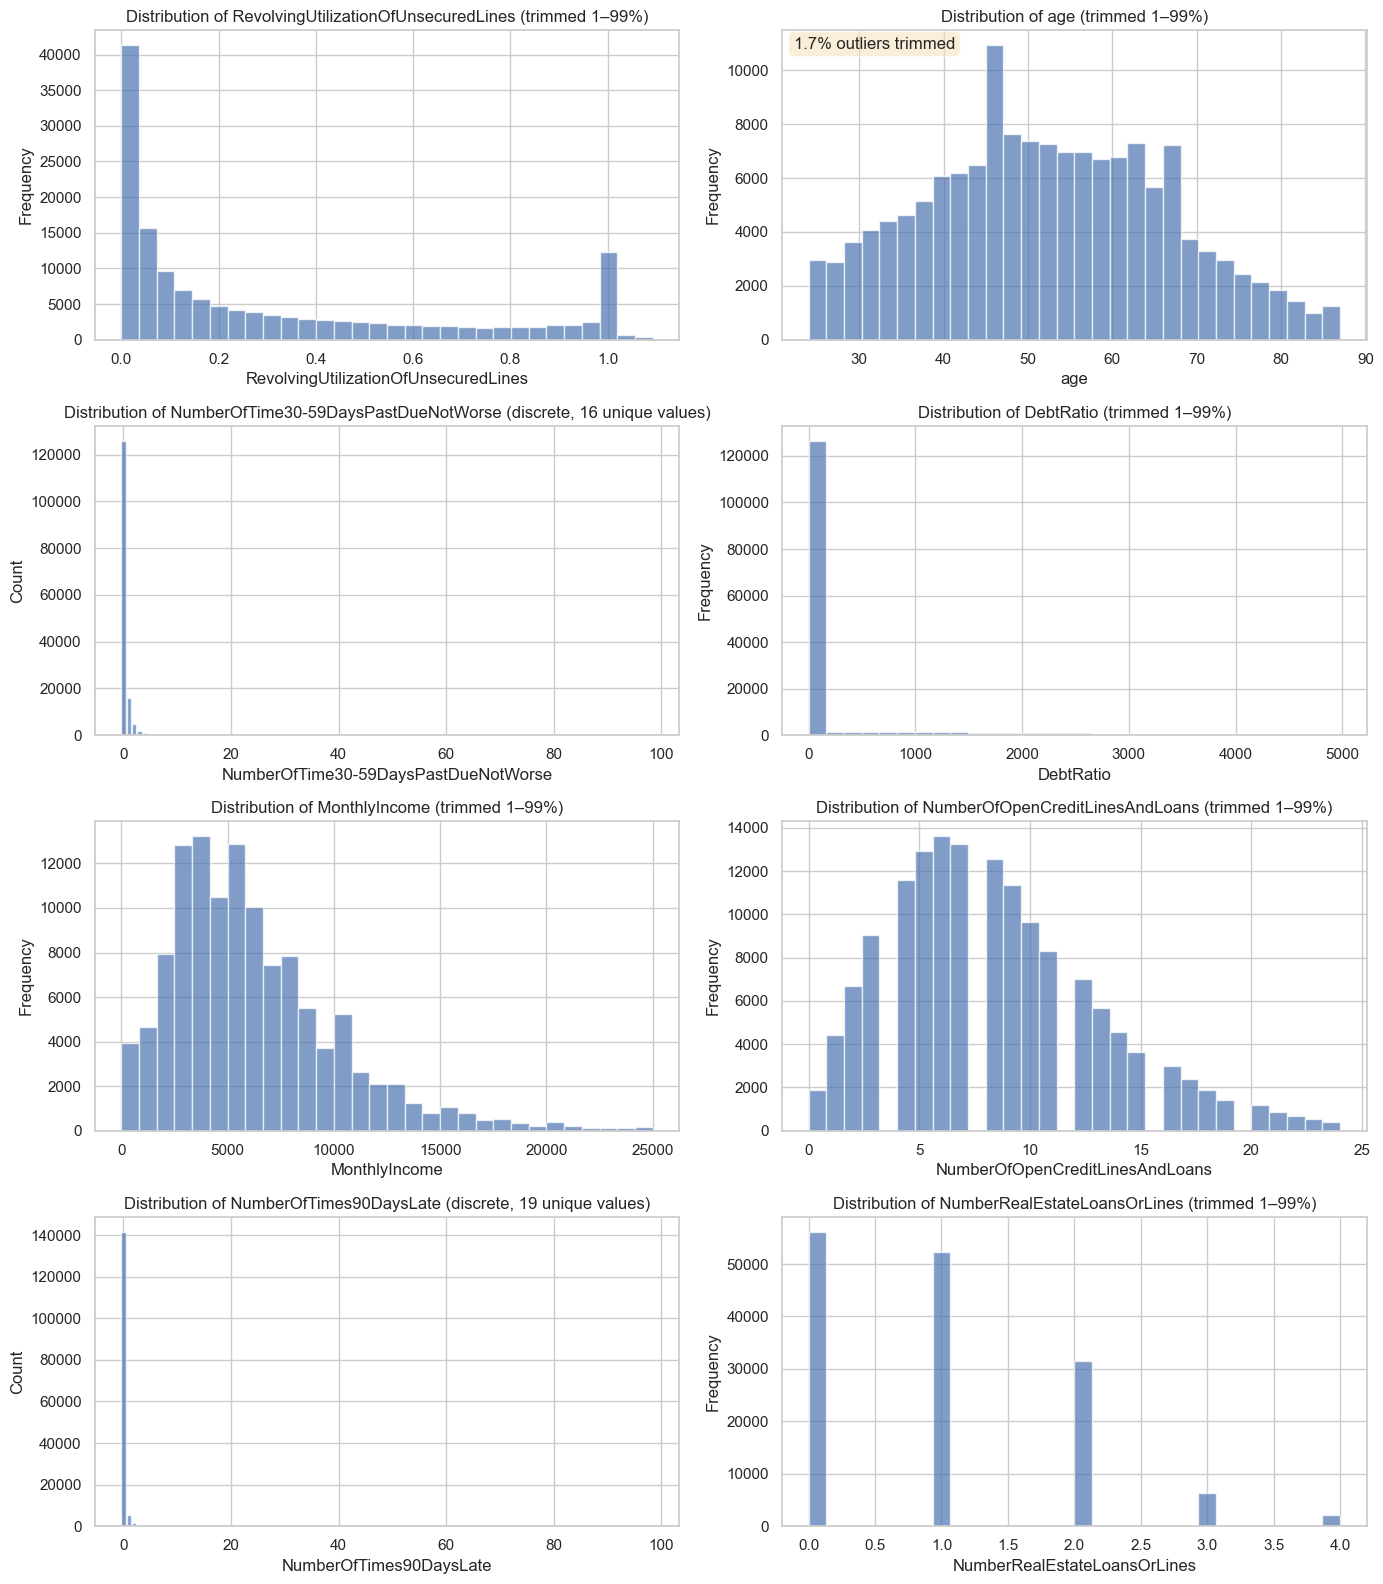

In [8]:
HAS_SEABORN = False
import math

df_plot = df
# Select numeric columns (excluding the target if desired)
numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in numeric_cols:
    numeric_feature_cols = [col for col in numeric_cols if col != TARGET_COL]
else:
    numeric_feature_cols = numeric_cols

print("Numeric feature columns used for plots:")
print(numeric_feature_cols)

max_plots = min(8, len(numeric_feature_cols))
cols_to_plot = numeric_feature_cols[:max_plots]

ncols = 2
nrows = math.ceil(max_plots / ncols) if max_plots > 0 else 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols_to_plot):
    values = df_plot[col].dropna()
    n_unique = values.nunique()

    # Treat low-cardinality numeric variables as discrete
    if n_unique <= 20:
        # Discrete variable: bar plot of value counts
        value_counts = values.value_counts().sort_index()
        ax.bar(value_counts.index, value_counts.values, alpha=0.7)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of {col} (discrete, {n_unique} unique values)")
    else:
        # Continuous variable: trim extremes to focus on bulk of the data
        q1, q99 = values.quantile([0.01, 0.99])
        values_trimmed = values[(values >= q1) & (values <= q99)]

        if HAS_SEABORN:
            import seaborn as sns

            # Let seaborn choose bins automatically
            sns.histplot(values_trimmed, kde=False, ax=ax, bins="auto")
        else:
            # Fallback: simple histogram with a reasonable bin count
            ax.hist(values_trimmed, bins=30, alpha=0.7)

        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.set_title(f"Distribution of {col} (trimmed 1–99%)")

        # Optional: annotate if many points were trimmed as outliers
        outliers_pct = ((values < q1) | (values > q99)).sum() / len(values) * 100
        if outliers_pct > 1:
            ax.text(
                0.02,
                0.98,
                f"{outliers_pct:.1f}% outliers trimmed",
                transform=ax.transAxes,
                va="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
            )

# Hide any unused subplots
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.1 Variable Distribution Interpretation

*(Your explanation here)*

For each numeric feature, address:
- Is the distribution approximately symmetric, or heavily skewed?
- Are there heavy tails or extreme values that stand out visually?
- Is the range plausible given the variable's definition in the data dictionary?
- Does the distribution suggest potential predictive signal?

Focus your narrative on the **3–4 most notable findings**. A comparative summary is more useful than one paragraph per feature.

## 5. Outlier Inspection

Focus on variables where extreme values are economically impossible or legally questionable.

RevolvingUtilizationOfUnsecuredLines > 1.0: 3,321 rows (2.21%)
Max value: 50708.0000
99th percentile: 1.0930
95th percentile: 1.0000


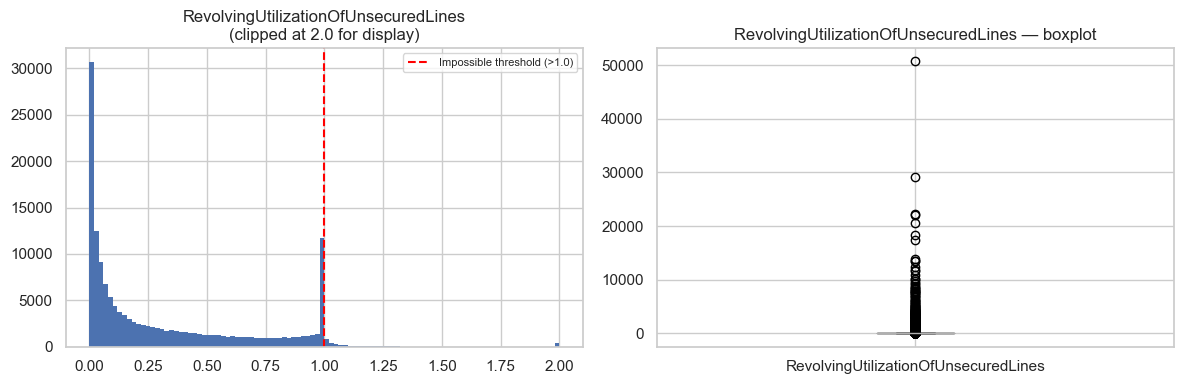


age < 18: 1 rows
Min age: 0

Age distribution for age < 25:
0       1
21    183
22    434
23    641
24    816
Name: age, dtype: int64


In [7]:
# 5a. RevolvingUtilizationOfUnsecuredLines: values > 1.0 are economically impossible
util_col = 'RevolvingUtilizationOfUnsecuredLines'
util_extreme = df[df[util_col] > 1.0]

print(f'{util_col} > 1.0: {len(util_extreme):,} rows ({len(util_extreme)/len(df):.2%})')
print(f'Max value: {df[util_col].max():.4f}')
print(f'99th percentile: {df[util_col].quantile(0.99):.4f}')
print(f'95th percentile: {df[util_col].quantile(0.95):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[util_col].clip(upper=2.0).hist(bins=100, ax=axes[0], color='#4C72B0', edgecolor='none')
axes[0].set_title(f'{util_col}\n(clipped at 2.0 for display)')
axes[0].axvline(1.0, color='red', linestyle='--', label='Impossible threshold (>1.0)')
axes[0].legend(fontsize=8)
df.boxplot(column=util_col, ax=axes[1])
axes[1].set_title(f'{util_col} — boxplot')
plt.tight_layout()
plt.show()

# 5b. age: values < 18 are legally questionable for a consumer loan dataset
age_col = 'age'
age_extreme = df[df[age_col] < 18]
print(f'\nage < 18: {len(age_extreme):,} rows')
print(f'Min age: {df[age_col].min()}')
print(f'\nAge distribution for age < 25:')
print(df[df[age_col] < 25][age_col].value_counts().sort_index())

### 5.1 Outlier Treatment Rationale

*(Your explanation here)*

**For `RevolvingUtilizationOfUnsecuredLines > 1.0`:**
- How many rows? What percentage of the dataset?
- Is this a data entry error, a scrubbing artefact, or a legitimate extreme value?
- Proposed treatment and rationale (options: cap at 1.0, winsorize at 99th pct, log-transform, leave with documentation)
- What is the validator's concern: extreme values here could distort the LR coefficient

**For `age < 18`:**
- How many rows? What specific values appear?
- Most likely explanation?
- Proposed treatment and rationale
- Does this raise a concern about the population the model was trained on?

**General:** Are there other variables where you observed values outside their plausible economic range? Document them or explicitly note their absence.

## 6. Correlation Analysis

Correlations with target (SeriousDlqin2yrs):
NumberOfTime30-59DaysPastDueNotWorse    0.1260
NumberOfTimes90DaysLate                 0.1170
age                                    -0.1150
NumberOfTime60-89DaysPastDueNotWorse    0.1020
NumberOfDependents                      0.0460
NumberOfOpenCreditLinesAndLoans        -0.0300
MonthlyIncome                          -0.0200
DebtRatio                              -0.0080
NumberRealEstateLoansOrLines           -0.0070
RevolvingUtilizationOfUnsecuredLines   -0.0020
Name: SeriousDlqin2yrs, dtype: float64


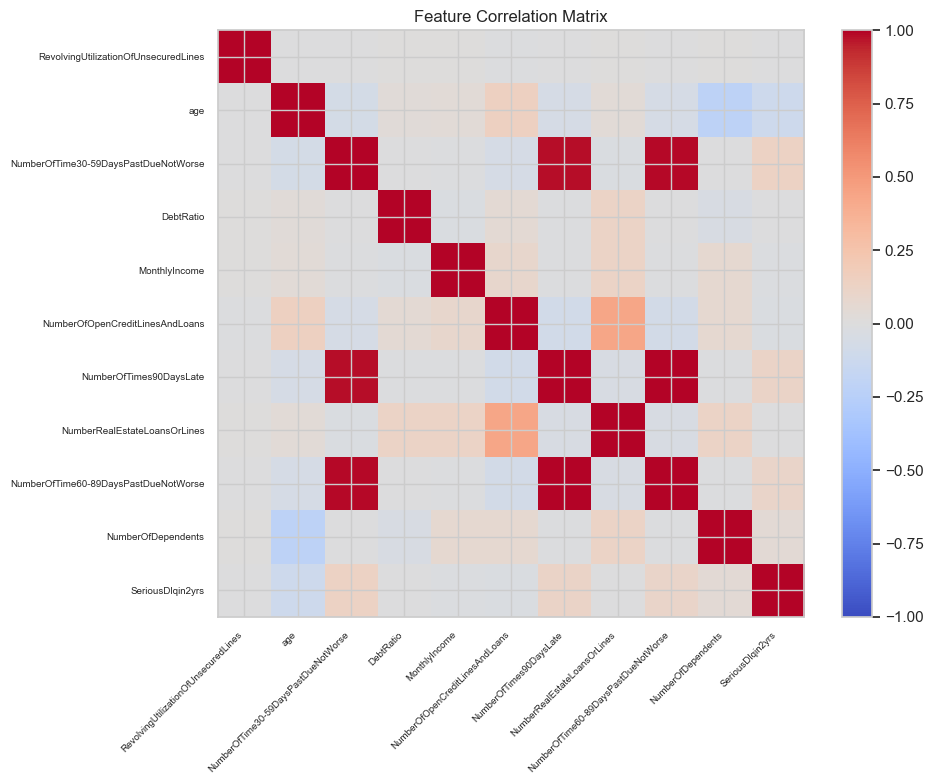

In [9]:
corr_matrix = df[numeric_feature_cols + [TARGET_COL]].corr()

target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print('Correlations with target (SeriousDlqin2yrs):')
print(target_corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
if HAS_SEABORN:
    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        corr_matrix, mask=mask, cmap='coolwarm', center=0,
        annot=True, fmt='.2f', annot_kws={'size': 8},
        square=True, linewidths=0.5, ax=ax
    )
else:
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(corr_matrix.columns, fontsize=7)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 6.1 Correlation Interpretation

*(Your explanation here)*

Address:
1. Which features show the strongest correlation with the target? Do the directions match your theoretical expectations?
2. Are there highly correlated feature pairs (|r| > 0.5)? Which pairs? Does this suggest multicollinearity risk for LR?
3. Are there features with near-zero correlation with the target? Is this a conceptual soundness concern, or might the relationship be non-linear?
4. Does anything in the correlation matrix surprise you from a credit-risk perspective? **Surprises are findings — document them.**

## 7. Variable Reasonableness Assessment

For each feature, assess whether it is theoretically motivated as a predictor of default in a consumer credit context.  
Reference: the Data Dictionary (`Data_Dictionary.md` from Week 1).

In [ ]:
target_corr_for_table = corr_matrix[TARGET_COL].drop(TARGET_COL).round(3)
print('Observed correlations with target — use these to fill in the table below:')
print(target_corr_for_table.to_string())

### 7.1 Variable Reasonableness Table

*(Your explanation here)*

Complete this table for all 10 features. Write it in markdown in this cell.

| Variable | Expected direction | Observed direction | Match? | Concerns / Notes |
|---|---|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | Higher → more default | *[check corr sign]* | *[Y/N/Partial]* | Values > 1.0 economically impossible |
| age | *[your expectation — state rationale]* | *[check corr sign]* | *[Y/N/Partial]* | Values < 18 present |
| NumberOfTime30-59DaysPastDueNotWorse | Higher → more default | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| DebtRatio | *[your expectation]* | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| MonthlyIncome | *[your expectation]* | *[check corr sign]* | *[Y/N/Partial]* | 21% missing |
| NumberOfOpenCreditLinesAndLoans | *[ambiguous — state why]* | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| NumberOfTimes90DaysLate | Higher → more default | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| NumberRealEstateLoansOrLines | *[your expectation]* | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| NumberOfTime60-89DaysPastDueNotWorse | Higher → more default | *[check corr sign]* | *[Y/N/Partial]* | *[any?]* |
| NumberOfDependents | *[ambiguous — state why]* | *[check corr sign]* | *[Y/N/Partial]* | 3% missing |

For any "No" or "Partial" match: explain the discrepancy in 1–2 sentences. Is it a data problem, a theoretical ambiguity, or a genuine surprise that warrants a validator finding?

## 8. Conceptual Soundness Summary

Synthesize your findings into a summary paragraph. This becomes the opening of **Section 1** in your final validation report — it should stand alone.

### 8.1 Summary

*(Your explanation here)*

Write 3–5 sentences covering:
1. Overall data quality: are there material quality concerns?
2. The most significant data treatment decisions and their justifications (or limitations)
3. Whether the feature set is theoretically motivated for this prediction task
4. The top 1–2 assumptions you are making about the data
5. Your overall conceptual soundness assessment:

> *"The model's inputs are [theoretically motivated / partially motivated / not adequately justified] for predicting credit default on this population, subject to the following concerns: [list the top 2–3]."*

A reader of your final report who reads only this paragraph should understand the main data quality and design findings without reading the supporting cells.